# Day 37: Feature Importance Analysis
**Author:** Sahil-K-Y  
**Phase:** 3 - Tree Models & SVM  
**Date:** Day 037

---

## 1. Impurity-based importances (MDI)

MDI calculates feature importances based on how much a feature decreases split impurity (Gini or entropy) averaged across all trees in the forest.
$$\text{MDI}(j) = \frac{1}{B} \sum_{T} \sum_{t \in T: v(t)=j} \Delta I(t)$$
- **The Cardinality Bias**: High-cardinality continuous features naturally present many split points. Greedy split metrics select them repeatedly, inflating their impurity reduction score regardless of true prediction value.

## 2. Permutation Feature Importance

Permutation Importance measures test-score drops when column $j$ is randomly shuffled, breaking its correlation with target $y$:
$$I(j) = s_{\text{base}} - s_{\text{permuted}}^{(j)}$$
- **Advantage**: Bypasses MDI cardinality bias because calculations occur on test data.

## 3. Selecting Features via Random Forest

Using `SelectFromModel` selects the subset of features whose importances are above a given threshold, pruning features to optimize model speed and generalizability.

## Exercise 1: Comparing MDI vs. Permutation Importance and Selecting Features

We will generate a dataset containing predictive columns and a high-cardinality noise column to demonstrate MDI bias, then apply SelectFromModel to prune the features.

### Step 1.1: Load Dataset and Append Cardinality Noise

In [1]:
import numpy as np
from sklearn.datasets import make_classification

# 1. Classification dataset banayenge jismein total 10 features hain (jinme se 4 informative hain)
X, y = make_classification(
    n_samples=1000, 
    n_features=10, 
    n_informative=4, 
    n_redundant=0, 
    random_state=42
)

# 2. Ek high-cardinality continuous random noise column (0 se 1 ke random numbers) add karenge
noise_column = np.random.RandomState(42).rand(X.shape[0], 1)
X_with_noise = np.hstack([X, noise_column])

print(f"Original X shape: {X.shape} | X with noise shape: {X_with_noise.shape}")

Original X shape: (1000, 10) | X with noise shape: (1000, 11)


### Step 1.2: Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

# Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_with_noise, y, test_size=0.2, random_state=42
)
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

Train Shape: (800, 11) | Test Shape: (200, 11)


### Step 1.3: Training the Random Forest and Extracting MDI Importances

In [3]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Random Forest train karenge
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 2. MDI feature importances nikaal kar Pandas Series mein save kar rahe hain
feature_names = [f"Feature {i}" for i in range(10)] + ["Noise (High Cardinality)"]
mdi_importances = pd.Series(rf.feature_importances_, index=feature_names)

print("--- MDI (Gini) Feature Importances ---")
print(mdi_importances.sort_values(ascending=False))

--- MDI (Gini) Feature Importances ---
Feature 9                   0.226073
Feature 0                   0.217271
Feature 5                   0.177914
Feature 6                   0.137839
Feature 7                   0.037616
Noise (High Cardinality)    0.037574
Feature 3                   0.036612
Feature 2                   0.033736
Feature 1                   0.033330
Feature 4                   0.031731
Feature 8                   0.030305
dtype: float64


### Step 1.4: Calculating Permutation Importances on the Test Set

In [4]:
from sklearn.inspection import permutation_importance

# Unseen Test set par permutation importance compute kar rahe hain
perm_importance = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_series = pd.Series(perm_importance.importances_mean, index=feature_names)

print("--- Permutation Feature Importances (Test Set) ---")
print(perm_series.sort_values(ascending=False))

--- Permutation Feature Importances (Test Set) ---
Feature 9                   0.2620
Feature 5                   0.1580
Feature 0                   0.1260
Feature 6                   0.0605
Feature 3                   0.0035
Feature 1                   0.0010
Feature 4                   0.0005
Feature 2                   0.0000
Feature 8                  -0.0015
Feature 7                  -0.0035
Noise (High Cardinality)   -0.0075
dtype: float64


### Step 1.5: Plotting the Importances Side-by-Side

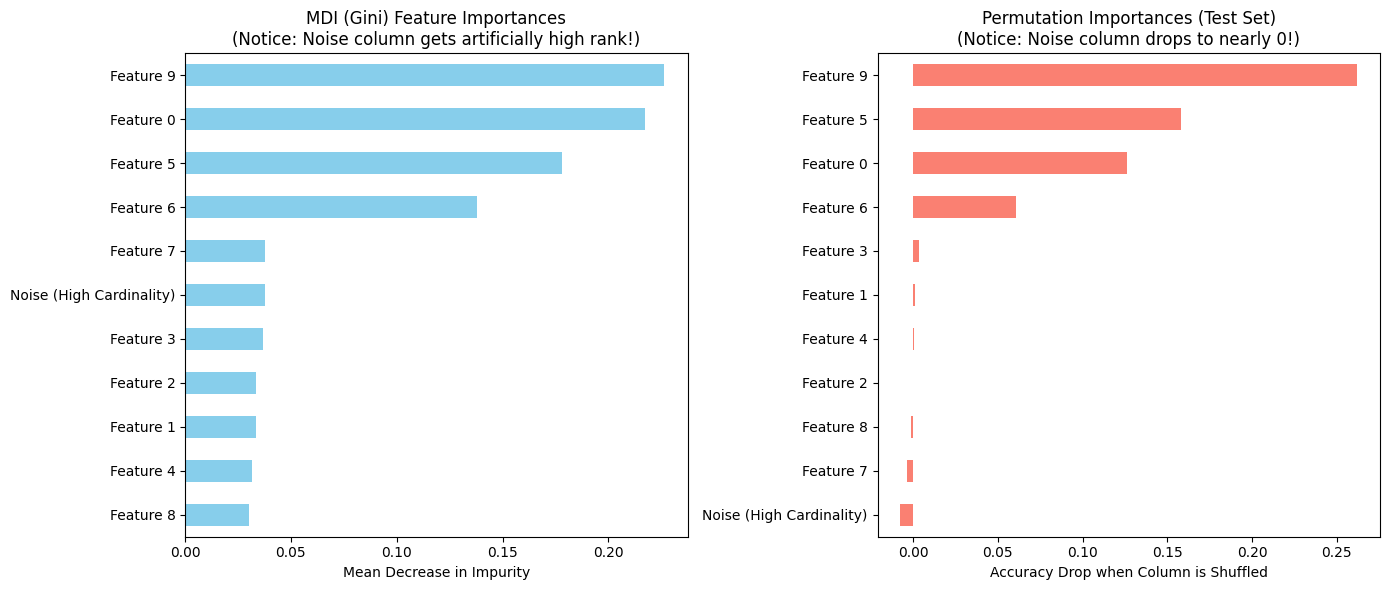

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: MDI Importances (Gini)
mdi_importances.sort_values().plot.barh(ax=ax[0], color='skyblue')
ax[0].set_title("MDI (Gini) Feature Importances\n(Notice: Noise column gets artificially high rank!)")
ax[0].set_xlabel("Mean Decrease in Impurity")

# Plot 2: Permutation Importances (Test Set)
perm_series.sort_values().plot.barh(ax=ax[1], color='salmon')
ax[1].set_title("Permutation Importances (Test Set)\n(Notice: Noise column drops to nearly 0!)")
ax[1].set_xlabel("Accuracy Drop when Column is Shuffled")

plt.tight_layout()
plt.show()

### Step 1.6: Selecting Top Predictive Features via SelectFromModel

In [6]:
from sklearn.feature_selection import SelectFromModel

# SelectFromModel se sirf important features ko select kar rahe hain
selector = SelectFromModel(rf, threshold='median', prefit=True)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print(f"Original Features count: {X_train.shape[1]}")
print(f"Selected Features count: {X_train_selected.shape[1]}")

Original Features count: 11
Selected Features count: 6


### Step 1.7: Evaluating the Pruned Feature Subset

In [7]:
from sklearn.metrics import accuracy_score

# 1. All features ke sath accuracy (Pehle wale model se)
full_acc = accuracy_score(y_test, rf.predict(X_test))

# 2. Naya model banayenge jo sirf Selected Features par train hoga
pruned_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pruned_rf.fit(X_train_selected, y_train)

pruned_acc = accuracy_score(y_test, pruned_rf.predict(X_test_selected))

print("--- Model Comparison ---")
print(f"Accuracy with ALL Features (11 cols):     {full_acc:.4f}")
print(f"Accuracy with SELECTED Features only:     {pruned_acc:.4f}")

--- Model Comparison ---
Accuracy with ALL Features (11 cols):     0.9150
Accuracy with SELECTED Features only:     0.9150
